# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

In [1]:
dados_gene = {
    'BRCA1': [5, 'BR', 1, False],
    'TP53': [4, 'TP', 0, False],
    'APOE': [4, 'AP', 1, False],
    'MTHFR': [5, 'MT', 0, False],
    'EGFR': [4, 'EG', 0, False]
}

import pandas as pd

df_genes = pd.DataFrame.from_dict(dados_gene, orient='index')
df_genes.columns = ['Tamanho_nucleotideo', 'Sigla_Prefixo', 'Contagem_A', 'Status_HU']
df_genes.to_csv('dados_geneticos.csv')

print("Arquivo 'dados_geneticos.csv' criado com sucesso neste notebook!")

Arquivo 'dados_geneticos.csv' criado com sucesso neste notebook!


## 01 – Descreva o racional da sua resposta:

R.: Primeiramente, usei de.str.len() para extrair o comprimento dos nomes dos genes, em seguida usei o método .value.counts(), para contabilizar quantas vezes cada comprimento aparecia no conjunto, isso gerou a tabela de frequência. Usei de .map() para integrar com o DataFrame original.

## 02 – Desenhe o fluxograma da resposta:

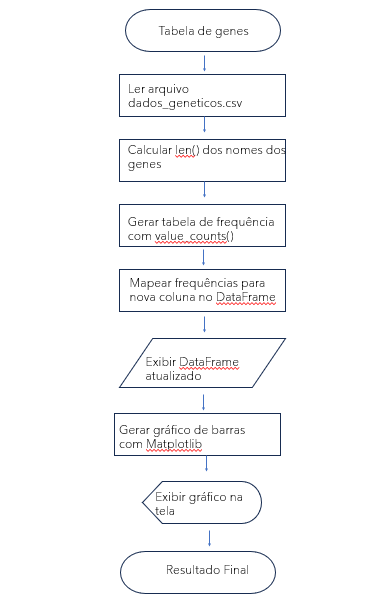

## 03 – Escreva o programa em Python:

DataFrame com a coluna de frequência:
       Tamanho_nucleotideo Sigla_Prefixo  Contagem_A  Status_HU  \
BRCA1                    5            BR           1      False   
TP53                     4            TP           0      False   
APOE                     4            AP           1      False   
MTHFR                    5            MT           0      False   
EGFR                     4            EG           0      False   

       Frequencia_tam_nome  
BRCA1                    2  
TP53                     3  
APOE                     3  
MTHFR                    2  
EGFR                     3  


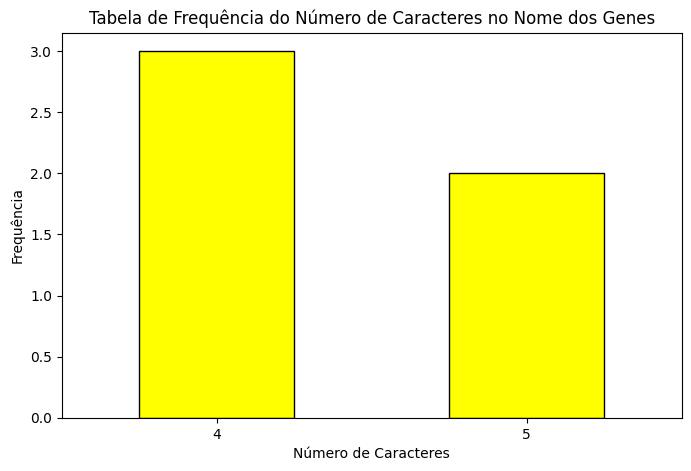

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df_genes = pd.read_csv('dados_geneticos.csv', index_col=0)

contagem_caracteres = df_genes.index.str.len()
tabela_freq = contagem_caracteres.value_counts()
df_genes['Frequencia_tam_nome'] = df_genes.index.str.len().map(tabela_freq)

print("DataFrame com a coluna de frequência:")
print(df_genes)

plt.figure(figsize=(8, 5))
tabela_freq.plot(kind='bar', color='yellow', edgecolor='black')

plt.title('Tabela de Frequência do Número de Caracteres no Nome dos Genes')
plt.xlabel('Número de Caracteres')
plt.ylabel('Frequência')
plt.xticks(rotation=0)
plt.show()


## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: Utilizei de estruturas de repetição e dicionários para contagem estatística. Primeiramente recuperei a lista com o nome dos genes, para ter a frequência usei do laço for. Por fim, criei uma nova lista de freqência correspondente a cada linha do DataFrame e deixei como uma coluna nova.

## 05 – Desenhe o fluxograma da resposta:

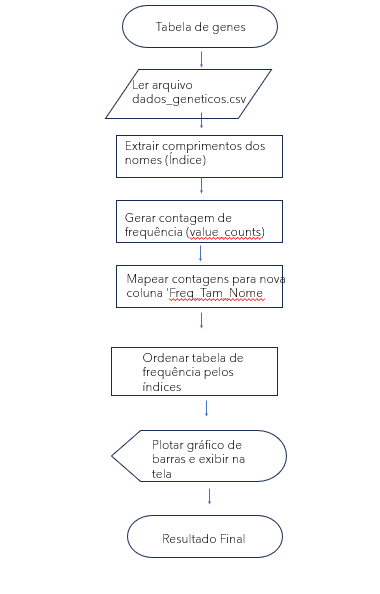

## 06 – Escreva o programa em Python:

DataFrame atualizado:
       Tamanho_nucleotideo Sigla_Prefixo  Contagem_A  Status_HU  Freq_Tam_Nome
BRCA1                    5            BR           1      False              2
TP53                     4            TP           0      False              3
APOE                     4            AP           1      False              3
MTHFR                    5            MT           0      False              2
EGFR                     4            EG           0      False              3


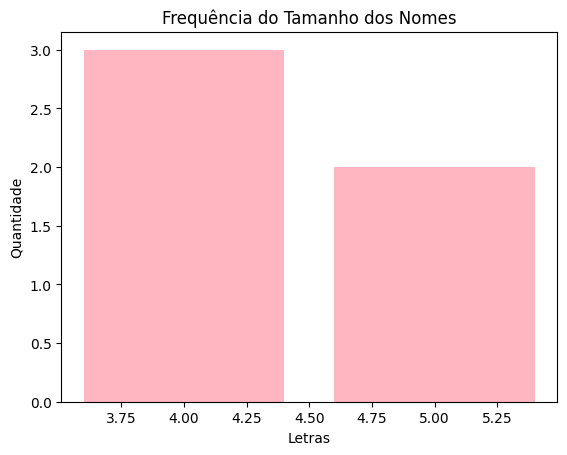

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df_genes = pd.read_csv('dados_geneticos.csv', index_col=0)
nomes_genes = df_genes.index
tamanhos = [len(gene) for gene in nomes_genes]

frequencias = {}

for n in tamanhos:
    if n in frequencias:
        frequencias[n] += 1
    else:
        frequencias[n] = 1
        lista_frequencia_final = []
for n in tamanhos:
    lista_frequencia_final.append(frequencias[n])

df_genes['Freq_Tam_Nome'] = lista_frequencia_final

print("DataFrame atualizado:")
print(df_genes)

plt.bar(frequencias.keys(), frequencias.values(), color='lightpink')
plt.title('Frequência do Tamanho dos Nomes')
plt.xlabel('Letras')
plt.ylabel('Quantidade')
plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [12]:
import pandas as pd

df_genes = pd.read_csv('dados_geneticos.csv', index_col=0)

colunas_para_remover = ['Sigla_Prefixo', 'Contagem_A', 'Status_HU']
df_reorganizado = df_genes.drop(columns=colunas_para_remover)

df_reorganizado = df_reorganizado.rename(columns={'Tamanho_nucleotideo': 'Tamanho'})

df_reorganizado['Amostra'] = 'Amostra 1'

print("DataFrame Organizado:")
print(df_reorganizado)

DataFrame Organizado:
       Tamanho    Amostra
BRCA1        5  Amostra 1
TP53         4  Amostra 1
APOE         4  Amostra 1
MTHFR        5  Amostra 1
EGFR         4  Amostra 1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [19]:
import numpy as np
import pandas as pd

def gerar_amostra_frequencia():
    valores = np.random.randint(1, 10, 5)
    contagem = {}

    for v in valores:
        if v in contagem:
            contagem[v] += 1
        else:
            contagem[v] = 1

    lista_freq = []
    for v in valores:
        lista_freq.append(contagem[v])

    return lista_freq

print("DataFrame com Amostra 2:")
print(df_reorganizado)

DataFrame com Amostra 2:
       Tamanho    Amostra
BRCA1        5  Amostra 1
TP53         4  Amostra 1
APOE         4  Amostra 1
MTHFR        5  Amostra 1
EGFR         4  Amostra 1


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [22]:
import pandas as pd

def gerar_amostra_frequencia():
    valores = np.random.randint(1, 10, 5)
    contagem = {}
    for v in valores:
        if v in contagem:
            contagem[v] += 1
        else:
            contagem[v] = 1

    lista_freq = []
    for v in valores:
        lista_freq.append(contagem[v])

    return lista_freq

df_reorganizado['Amostra 3'] = gerar_amostra_frequencia()
df_reorganizado['Amostra 4'] = gerar_amostra_frequencia()
df_reorganizado['Amostra 5'] = gerar_amostra_frequencia()
df_reorganizado['Amostra 6'] = gerar_amostra_frequencia()

print(df_reorganizado)

       Tamanho    Amostra  Amostra 3  Amostra 4  Amostra 5  Amostra 6
BRCA1        5  Amostra 1          2          1          1          2
TP53         4  Amostra 1          2          2          1          1
APOE         4  Amostra 1          2          1          1          1
MTHFR        5  Amostra 1          1          2          1          2
EGFR         4  Amostra 1          2          1          1          1


## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

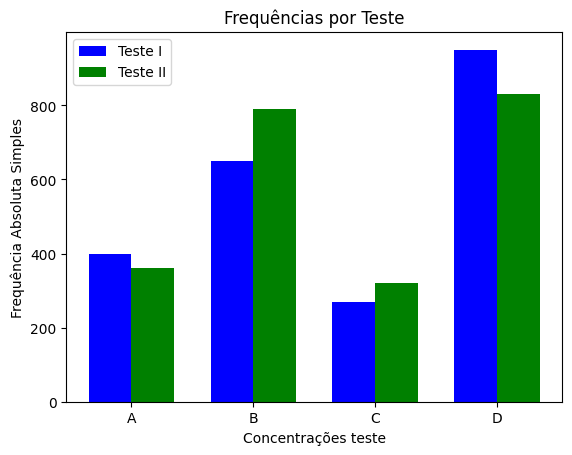

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

categorias = ['A', 'B', 'C', 'D']
teste1 = [400, 650, 270, 950]
teste2 = [360, 790, 320, 830]

teste1_rep = [x + np.random.randint(-20, 20) for x in teste1]
teste2_rep = [x + np.random.randint(-20, 20) for x in teste2]

x = np.arange(len(categorias))
largura = 0.35

plt.bar(x - largura/2, teste1, largura, label='Teste I', color='blue')
plt.bar(x + largura/2, teste2, largura, label='Teste II', color='green')

plt.ylabel('Frequência Absoluta Simples')
plt.xlabel('Concentrações teste')
plt.title('Frequências por Teste')
plt.xticks(x, categorias)
plt.legend()

plt.show()